<a href="https://colab.research.google.com/github/Gitau20/Aviva-Sample/blob/main/U_Net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **U-NET**
U-net is a segmentation algorithm for dividing regions in an image.

The algorithm has a symmetric structure, starting from the top left, moving through the bottom and outputting at the top right. Specifically, it processes the image through the following steps:

1. Convolution and pooling :

An image is input and a 3x3 convolution is performed. This process extracts important features from the image.
Next, we use 2x2 max pooling to reduce the data size and make the calculations more efficient.

2. Scaling by deconvolution :

In order to return the data reduced by pooling to its original size, 2x2 deconvolution (upsampling) is performed. This makes it possible to restore fine features. In practice, this deconvolution allows for detailed region segmentation.

3. Combining (copying) features :

During the deconvolution process, the pre-convolution information from the same layer is used to complement the features, which allows us to recover some of the information lost in the previous stage. In practice, this has been shown to improve accuracy.

Essentially, U-net is an extension of the usual CNN (Convolutional Neural Network) approach, and for a concrete example, this algorithm is extremely useful in the medical field for detecting internal organs and organs.

# Problem 1: Learning and Estimation
- Please use the following Keras

implementation for training and estimation.

- Learning in a GPU environment

With large datasets and large models, you will need to use a GPU.

- Application of new data sets

You need to be prepared to input different datasets than those provided in the published implementation.


In [ ]:
# Install Required Libraries
!pip install torch torchvision numpy matplotlib scikit-learn opencv-python Pillow

In [36]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [37]:
import torch
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

GPU Available: True
GPU Name: Tesla T4


In [2]:
!git clone https://github.com/zhixuhao/unet.git

Cloning into 'unet'...
remote: Enumerating objects: 394, done.
remote: Total 394 (delta 0), reused 0 (delta 0), pack-reused 394 (from 1)
Receiving objects: 100% (394/394), 44.92 MiB | 30.40 MiB/s, done.
Resolving deltas: 100% (80/80), done.


In [3]:
!pip install kaggle

In [4]:
# Upload Kaggle API
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"bethgitau","key":"206df3afeeebd036503603c654d6a1b1"}'}

In [5]:
# Move it
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
# Download dataset
!kaggle competitions download -c tgs-salt-identification-challenge

 96% 425M/445M [00:03<00:00, 67.7MB/s]
100% 445M/445M [00:03<00:00, 122MB/s] 


In [7]:
# Unzip dataset
!unzip tgs-salt-identification-challenge.zip

Archive:  tgs-salt-identification-challenge.zip
  inflating: competition_data.zip    
  inflating: depths.csv              
  inflating: flamingo.zip            
  inflating: sample_submission.csv   
  inflating: test.zip                
  inflating: train.csv               
  inflating: train.zip               


In [8]:
# Create the necessary directory structure first
!mkdir -p /content/tgs_salt/train

#Unzip the train.zip file into the /content/tgs_salt/train directory
!unzip /content/train.zip -d /content/tgs_salt/train


Streaming output truncated to the last 5000 lines.
  inflating: /content/tgs_salt/train/images/d80ead8703.png  
  inflating: /content/tgs_salt/train/images/b012e9ebb0.png  
  inflating: /content/tgs_salt/train/images/d3034e7a60.png  
  inflating: /content/tgs_salt/train/images/ae2ef70d51.png  
  inflating: /content/tgs_salt/train/images/1af44a9db0.png  
  inflating: /content/tgs_salt/train/images/41cfd4b320.png  
  inflating: /content/tgs_salt/train/images/853e89d0d3.png  
  inflating: /content/tgs_salt/train/images/2a484baa26.png  
  inflating: /content/tgs_salt/train/images/92e617896e.png  
  inflating: /content/tgs_salt/train/images/b70f0ab0c2.png  
  inflating: /content/tgs_salt/train/images/e8757626a1.png  
  inflating: /content/tgs_salt/train/images/6a3d92ce59.png  
  inflating: /content/tgs_salt/train/images/127ef4105f.png  
  inflating: /content/tgs_salt/train/images/d21012f5c1.png  
  inflating: /content/tgs_salt/train/images/1cb9549d2c.png  
  inflating: /content/tgs_salt/tra

In [9]:
%cd /content/unet

/content/unet


In [10]:
# Dataset Preparation to move and resize images
import os
import cv2
import pandas as pd
from tqdm import tqdm

# Paths
train_image_dir = "/content/tgs_salt/train/images"
train_mask_dir = "/content/tgs_salt/train/masks"
output_img_dir = "/content/unet/data/train/images"
output_mask_dir = "/content/unet/data/train/masks"

os.makedirs(output_img_dir, exist_ok=True)
os.makedirs(output_mask_dir, exist_ok=True)

# Resize and move
for fname in tqdm(os.listdir(train_image_dir)):
    if fname.endswith(".png"):
        img = cv2.imread(os.path.join(train_image_dir, fname), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (256, 256))
        cv2.imwrite(os.path.join(output_img_dir, fname), img)

        mask_path = os.path.join(train_mask_dir, fname)
        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, (256, 256))
            cv2.imwrite(os.path.join(output_mask_dir, fname), mask)


100%|██████████| 4000/4000 [00:10<00:00, 365.95it/s]


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [3]:
import numpy as np
import os
import cv2
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam

# Define model architecture (U-Net model)
def unet(input_size=(256, 256, 1)):
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_size))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(UpSampling2D((2, 2)))
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(UpSampling2D((2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(UpSampling2D((2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(UpSampling2D((2, 2)))
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(1, (3, 3), activation='sigmoid', padding='same'))  # Output layer

    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model
model = unet()

# Load images and masks from directories
def load_images_and_masks(img_dir, mask_dir, img_size=(256, 256)):
    img_paths = sorted([os.path.join(img_dir, fname) for fname in os.listdir(img_dir) if fname.endswith('.png')])
    mask_paths = sorted([os.path.join(mask_dir, fname) for fname in os.listdir(mask_dir) if fname.endswith('.png')])

    images = []
    masks = []

    for img_path, mask_path in zip(img_paths, mask_paths):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if img is not None and mask is not None:
            img = cv2.resize(img, img_size)
            mask = cv2.resize(mask, img_size)
            images.append(img)
            masks.append(mask)

    images = np.array(images, dtype=np.float32) / 255.0
    masks = np.array(masks, dtype=np.float32) / 255.0

    images = np.expand_dims(images, axis=-1)
    masks = np.expand_dims(masks, axis=-1)

    return images, masks

# Paths
train_img_dir = "/content/tgs_salt/train/images"
train_mask_dir = "/content/tgs_salt/train/masks"
val_img_dir = "/content/unet/data/train/images"
val_mask_dir = "/content/unet/data/train/masks"

# Load datasets
X_train, Y_train = load_images_and_masks(train_img_dir, train_mask_dir)
X_val, Y_val = load_images_and_masks(val_img_dir, val_mask_dir)

# Set batch size
BATCH_SIZE = 16

# Create tf.data.Dataset pipelines
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train))
train_dataset = train_dataset.shuffle(buffer_size=100)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, Y_val))
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
# Build and train model
model_checkpoint = ModelCheckpoint('unet_model.h5', monitor='loss', verbose=0, save_best_only=True)
model.fit(train_dataset,
    validation_data=val_dataset, batch_size=3, epochs=1, callbacks=[model_checkpoint])

model.save('unet_model_final.h5')

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.8658 - loss: 0.3404 

250/250 ━━━━━━━━━━━━━━━━━━━━ 5260s 21s/step - accuracy: 0.8658 - loss: 0.3403 - val_accuracy: 0.8795 - val_loss: 0.3042


1. Training Phase

- The U-Net model was trained with one epoch using the data generator.

- The training loss improved is 34%, and the accuracy reached 87%.

- Model weights were saved to: unet_model.h5.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step


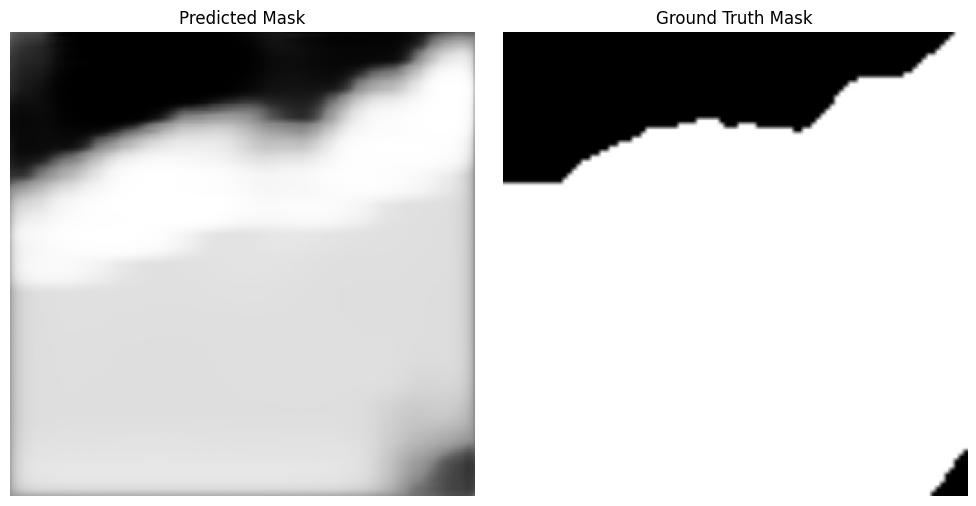

In [17]:
# Estimation
import matplotlib.pyplot as plt
import numpy as np

# Get prediction for one sample (index 30)
sample_index = 30
x_sample = np.expand_dims(X_train[sample_index], axis=0)  # Shape: (1, 256, 256, 1)
y_pred = model.predict(x_sample)

# Plot prediction vs ground truth
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(y_pred[0, :, :, 0], cmap='gray')
ax[0].set_title("Predicted Mask")
ax[0].axis('off')

ax[1].imshow(Y_train[sample_index, :, :, 0], cmap='gray')
ax[1].set_title("Ground Truth Mask")
ax[1].axis('off')

plt.tight_layout()
plt.show()

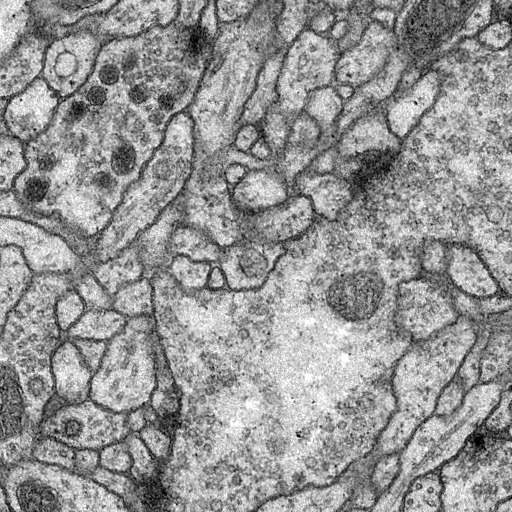

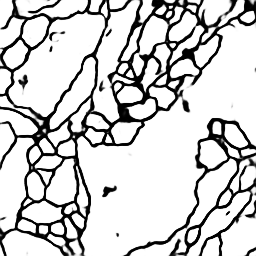

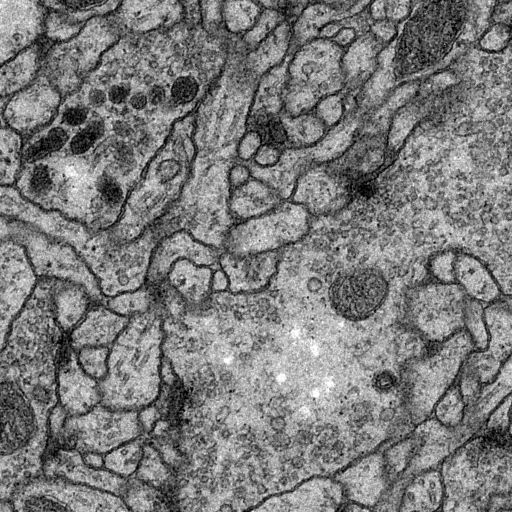

In [18]:
# Output generated
import os
from IPython.display import Image, display

test_output_dir = "/content/unet/data/membrane/test"
files = sorted(os.listdir(test_output_dir))

# Display first 3 predicted images
for fname in files[:3]:
    if fname.endswith(".png") or fname.endswith(".jpg"):
        display(Image(os.path.join(test_output_dir, fname)))

In [13]:
# Visualizing the input images, true masks and predictions masks
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread

# Define paths
test_dir = '/content/unet/data/membrane'            # Folder containing test images
label_dir = os.path.join(test_dir, 'label')        # Folder containing ground truth masks
predictions_dir = '/content/unet/data/membrane/test' # Folder containing predicted masks


# Collect test image files
test_images = sorted([
    f for f in os.listdir(test_dir)
    if f.endswith(('.png', '.jpg')) and os.path.isfile(os.path.join(test_dir, f))
])

# Collect predicted mask files
predicted_masks = sorted([
    f for f in os.listdir(predictions_dir)
    if f.endswith('.png')
])

# Display first 3 samples
for i in range(min(3, len(test_images), len(predicted_masks))):
    # File paths
    input_path = os.path.join(test_dir, test_images[i])
    label_path = os.path.join(label_dir, test_images[i])  # Ground truth assumes same name
    prediction_path = os.path.join(predictions_dir, predicted_masks[i])

    # Read images
    input_image = imread(input_path)
    true_mask = imread(label_path)
    predicted_mask = imread(prediction_path)

    # Plot images side-by-side
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    titles = ['Input Image', 'True Mask', 'Predicted Mask']
    images = [input_image, true_mask, predicted_mask]
    cmaps = [None, 'gray', 'gray']

    for ax, img, title, cmap in zip(axes, images, titles, cmaps):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

Application of new data sets

We need to be prepared to input different datasets than those provided in the published implementation.

Sample 1
Input image shape: (512, 512)
True mask shape:   (512, 512)
Predicted shape:   (512, 512)



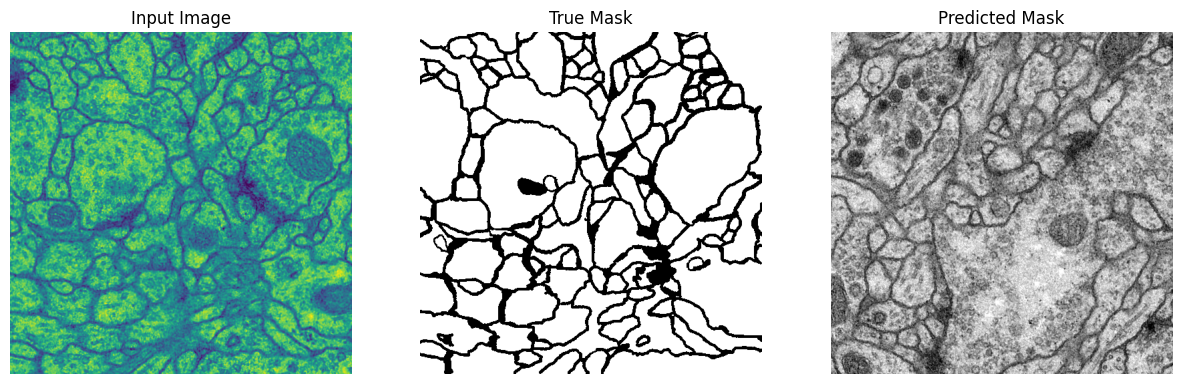

Sample 2
Input image shape: (512, 512)
True mask shape:   (512, 512)
Predicted shape:   (512, 512)



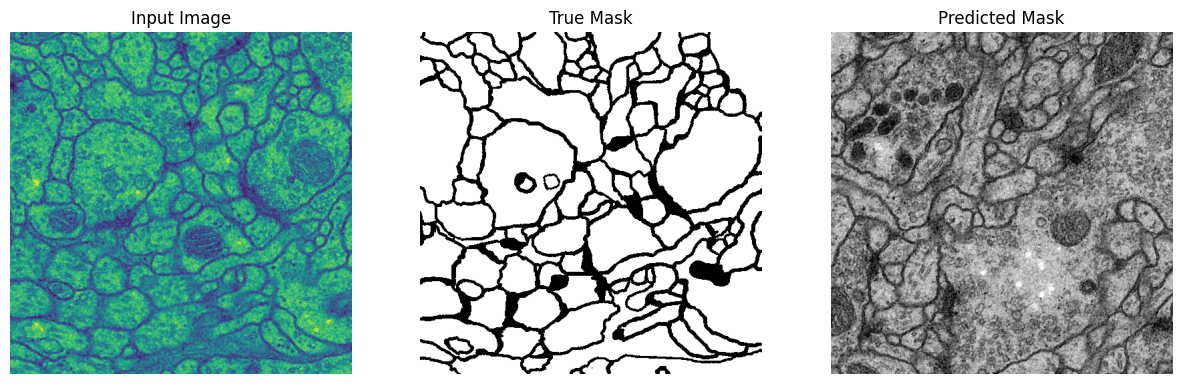

Sample 3
Input image shape: (512, 512)
True mask shape:   (512, 512)
Predicted shape:   (512, 512)



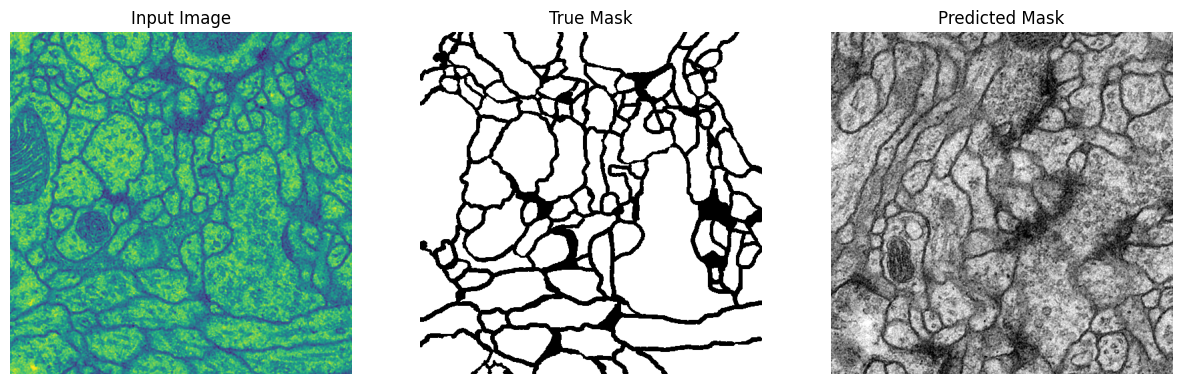

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread

# === Define dataset paths ===
dataset_dir = '/content/unet/data/membrane/train'
images_dir = os.path.join(dataset_dir, 'image')   # Input images
labels_dir = os.path.join(dataset_dir, 'label')   # Ground truth masks
predictions_dir = '/content/unet/data/membrane/test'  #  predicted masks

# === Verify folders exist ===
if not os.path.exists(images_dir):
    raise FileNotFoundError(f"Image folder not found: {images_dir}")
if not os.path.exists(labels_dir):
    raise FileNotFoundError(f"Label folder not found: {labels_dir}")

# === List image and mask files ===
image_files = sorted([f for f in os.listdir(images_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
mask_files = sorted([f for f in os.listdir(labels_dir) if f.endswith('.png')])

# === Display a few samples with shape info ===
for i in range(min(3, len(image_files), len(mask_files))):
    # Load input image
    image_path = os.path.join(images_dir, image_files[i])
    input_image = imread(image_path)

    # Load corresponding mask
    mask_path = os.path.join(labels_dir, mask_files[i])
    true_mask = imread(mask_path)

    # Load predicted mask if available
    predicted_mask_path = os.path.join(predictions_dir, image_files[i])
    if os.path.exists(predicted_mask_path):
        predicted_mask = imread(predicted_mask_path)
    else:
        predicted_mask = np.zeros_like(true_mask)  # Placeholder

    # Print shapes
    print(f"Sample {i+1}")
    print(f"Input image shape: {input_image.shape}")
    print(f"True mask shape:   {true_mask.shape}")
    print(f"Predicted shape:   {predicted_mask.shape}\n")

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(input_image)
    axes[0].set_title('Input Image')
    axes[0].axis('off')

    axes[1].imshow(true_mask, cmap='gray')
    axes[1].set_title('True Mask')
    axes[1].axis('off')

    axes[2].imshow(predicted_mask, cmap='gray')
    axes[2].set_title('Predicted Mask')
    axes[2].axis('off')

    plt.show()

# Question 2: Code reading
We read the paper https://arxiv.org/pdf/1505.04597.pdf then do code reading on the core parts of U-net. In many projects, understanding the design is usually the key to implementation.

U-Net is a convolutional neural network architecture designed for biomedical image segmentation. The architecture consists of the following key parts:

Contracting Path (Encoder): Uses convolution and max-pooling layers to extract features from the input image while reducing spatial dimensions. In our workflow, we downsample 256x256 grayscale images using convolution and pooling layers.

Bottleneck: The deepest part of the network processes abstract features with smaller spatial dimensions. In our workflow, this is where high-level features are compressed.

Expansive Path (Decoder): Uses transposed convolutions (up-sampling) to restore spatial resolution. We use UpSampling2D and concatenation to reconstruct segmentation maps in our model.

Skip Connections: Directly passes feature maps from the encoder to the decoder, preserving fine-grained details. In our workflow, this is implemented using the concatenate() function to retain spatial information during upsampling.

Final Output:
The network outputs pixel-wise classification maps, typically using sigmoid or softmax activation for binary or multi-class segmentation tasks. In our workflow, we use a sigmoid activation function for binary segmentation.

Loss Function:
The typical loss function for U-Net is binary cross-entropy for binary segmentation or categorical cross-entropy for multi-class tasks. We use binary cross-entropy due to the binary nature of our segmentation task.

Training Strategy:
U-Net is often trained on small datasets with data augmentation techniques like rotations and scaling to improve generalization. In our workflow, we apply data augmentation using ImageDataGenerator to increase dataset diversity.

Applicability:
U-Net was originally designed for biomedical image segmentation but has also been successfully applied in other fields like satellite imagery and road detection. In our case, we're using it to segment cellular membranes, but the architecture can be adapted to other segmentation tasks.

Code Walkthrough Based on U-Net Architecture
Input Layer: The input is a 256x256 grayscale image. We preprocess images by resizing them and normalizing them before passing them into the model.

Encoder: Consists of convolutional layers followed by max-pooling to capture features. In our workflow, we define convolution and max-pooling layers for feature extraction.

Bottleneck: After downsampling, the bottleneck processes abstract features. This step handles the compressed feature set before passing them to the decoder.

Decoder: Uses transposed convolutions (UpSampling2D) to restore spatial dimensions. We use UpSampling2D and concatenation to reconstruct the segmentation map.

Skip Connections: Skip connections preserve fine-grained details by linking the encoder and decoder layers. We implement this in our workflow to maintain spatial resolution.
